In [1]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import os

ROOT = Path("/content/drive/MyDrive/svg_llm_competition")
CFG_PATH = ROOT / "configs" / "base.yaml"

ADAPTERS = [
    ROOT / "artifacts" / "models" / "seed11" / "final",
    ROOT / "artifacts" / "models" / "seed11" / "checkpoint-5000",
]

Mounted at /content/drive


In [ ]:
!pip install -q transformers peft sentence-transformers faiss-cpu pandas pyarrow pyyaml tqdm lxml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 122.9 MB/s eta 0:00:00


In [2]:
import yaml

with open(CFG_PATH, "r") as f:
    cfg = yaml.safe_load(f)

cfg["test_csv"] = str(ROOT / "data" / "processed" / "test_clean.csv")
cfg["retrieval_dir"] = str(ROOT / "artifacts" / "retrieval")

cfg["candidate_temps"] = [0.2, 0.5]
cfg["candidate_top_ps"] = [0.9]
cfg["max_new_tokens"] = 220
cfg["generation_max_new_tokens"] = 220
cfg["retrieval_k"] = 1
cfg["retrieval_top_k"] = 1

with open(CFG_PATH, "w") as f:
    yaml.safe_dump(cfg, f, sort_keys=False)

In [ ]:
OUT_DIR = ROOT / "artifacts" / "better_inference"
OUT_DIR.mkdir(parents=True, exist_ok=True)

for adapter in ADAPTERS:
    out_file = OUT_DIR / f"{adapter.name.replace('-', '_')}_candidates.csv"
    print("=" * 80)
    print("ADAPTER:", adapter)
    print("OUTFILE:", out_file)
    print("=" * 80)

    !python -u {ROOT}/src/generate_candidates.py \
      --mode test \
      --config {CFG_PATH} \
      --adapter_dir {adapter} \
      --out_file {out_file}

Streaming output truncated to the last 5000 lines.
Loading weights:  18% 76/434 [00:00<00:01, 218.49it/s, Materializing param=model.layers.6.mlp.gate_proj.weight]
Loading weights:  18% 76/434 [00:00<00:01, 218.49it/s, Materializing param=model.layers.6.mlp.gate_proj.weight]
Loading weights:  18% 77/434 [00:00<00:01, 218.49it/s, Materializing param=model.layers.6.mlp.up_proj.weight]  
Loading weights:  18% 77/434 [00:00<00:01, 218.49it/s, Materializing param=model.layers.6.mlp.up_proj.weight]
Loading weights:  18% 78/434 [00:00<00:01, 218.49it/s, Materializing param=model.layers.6.post_attention_layernorm.weight]
Loading weights:  18% 78/434 [00:00<00:01, 218.49it/s, Materializing param=model.layers.6.post_attention_layernorm.weight]
Loading weights:  18% 79/434 [00:00<00:01, 218.49it/s, Materializing param=model.layers.6.self_attn.k_proj.bias]          
Loading weights:  18% 79/434 [00:00<00:01, 218.49it/s, Materializing param=model.layers.6.self_attn.k_proj.bias]
Loading weights:  18%

In [ ]:
import pandas as pd

cand_files = sorted((ROOT / "artifacts" / "better_inference").glob("*_candidates.csv"))
dfs = []
for f in cand_files:
    df = pd.read_csv(f)
    df["source_file"] = f.name
    dfs.append(df)

cand = pd.concat(dfs, ignore_index=True)
print("Total candidates:", len(cand))
cand.head()

Total candidates: 2000


,id,prompt,candidate_svg,temperature,top_p,svg_len,num_paths,num_circles,num_rects,num_groups,source_file
0,fa1d8fa7-080f-4269-a9cf-a17562c9a0ca,firewood stack cut logs wood with leaf illustr...,"<svg xmlns=""http://www.w3.org/2000/svg"" height...",0.2,0.9,319,4,0,0,1,final_candidates.csv
1,fa1d8fa7-080f-4269-a9cf-a17562c9a0ca,firewood stack cut logs wood with leaf illustr...,"<svg xmlns=""http://www.w3.org/2000/svg"" height...",0.5,0.9,319,4,0,0,1,final_candidates.csv
2,6eede943219547c22ac56085027d33cc,The image shows five horizontal lines of varyi...,"<svg xmlns=""http://www.w3.org/2000/svg"" viewBo...",0.2,0.9,162,1,0,0,0,final_candidates.csv
3,6eede943219547c22ac56085027d33cc,The image shows five horizontal lines of varyi...,"<svg xmlns=""http://www.w3.org/2000/svg"" viewBo...",0.5,0.9,155,1,0,0,0,final_candidates.csv
4,ea045c7a247166f061ce504d9b7ccaab,A stylized icon depicting a curved arrow withi...,"<svg xmlns=""http://www.w3.org/2000/svg"" viewBo...",0.2,0.9,162,1,0,0,0,final_candidates.csv


In [ ]:
import re

def heuristic_score(prompt: str, svg: str, svg_len: int, num_paths: int, num_circles: int, num_rects: int, num_groups: int):
    p = str(prompt).lower()
    score = 0.0

    # prefer moderate complexity
    score -= abs(svg_len - 1200) / 1000.0
    score -= abs(num_paths - 6) / 10.0

    # obvious bad cases
    if svg_len < 120:
        score -= 6
    if num_paths == 0 and num_circles == 0 and num_rects == 0:
        score -= 6
    if len(str(svg)) > 16000:
        score -= 10
    if len(re.findall(r"<path\b", str(svg))) > 256:
        score -= 10

    # prompt-aware bonuses
    if "circle" in p or "round" in p:
        score += 1.2 if num_circles > 0 else -1.4
    if "document" in p or "folder" in p or "box" in p or "rectangle" in p or "square" in p:
        score += 1.2 if num_rects > 0 else -1.2
    if "outline" in p or "line" in p:
        score += 0.4 if num_paths > 0 else -0.6
    if "stack" in p or "wood" in p or "leaf" in p or "tree" in p:
        score += 0.5 if num_paths >= 2 else -0.4
    if "lock" in p:
        score += 0.4 if (num_rects + num_paths) >= 2 else -0.5

    return score

cand["score"] = cand.apply(
    lambda r: heuristic_score(
        r["prompt"],
        r["candidate_svg"],
        int(r.get("svg_len", len(str(r["candidate_svg"])))),
        int(r.get("num_paths", 0)),
        int(r.get("num_circles", 0)),
        int(r.get("num_rects", 0)),
        int(r.get("num_groups", 0)),
    ),
    axis=1,
)

best = cand.sort_values(["id", "score"], ascending=[True, False]).drop_duplicates("id", keep="first")
print("Chosen rows:", len(best))
best[["id", "score", "source_file"]].head()

Chosen rows: 1000


,id,score,source_file
970,00dc7f04-c2ce-441b-8ebf-431d6d23eaec,-1.538,final_candidates.csv
1348,00f708cd3f4a7792afcfb4bc6dcb4017,-1.538,final_candidates.csv
870,012864599f873514017c173770026982,-1.538,final_candidates.csv
520,0139c8b5480769aed9b19064eacfa406,-4.133,final_candidates.csv
1338,01632c497e0bafb8ff07907f753a0fa8,-1.138,final_candidates.csv


In [ ]:
import pandas as pd
import re

test_df = pd.read_csv(ROOT / "data" / "raw" / "test.csv")

sub = test_df[["id"]].merge(
    best[["id", "candidate_svg"]],
    on="id",
    how="left",
).rename(columns={"candidate_svg": "svg"})

EMPTY_SVG = '<svg width="256" height="256" viewBox="0 0 256 256"></svg>'

def sanitize_svg(x):
    if pd.isna(x):
        return EMPTY_SVG
    x = str(x).strip()
    if not x.startswith("<svg"):
        return EMPTY_SVG
    if len(x) > 16000:
        return EMPTY_SVG
    if len(re.findall(r"<path\b", x)) > 256:
        return EMPTY_SVG
    return x

sub["svg"] = sub["svg"].map(sanitize_svg).fillna(EMPTY_SVG)

OUT_SUB = ROOT / "submissions" / "submission_better_inference.csv"
OUT_SUB.parent.mkdir(parents=True, exist_ok=True)
sub.to_csv(OUT_SUB, index=False)

print("Saved:", OUT_SUB)
print(sub.head())
print("Rows:", len(sub))

Saved: /content/drive/MyDrive/svg_llm_competition/submissions/submission_better_inference.csv
                                     id  \
0  fa1d8fa7-080f-4269-a9cf-a17562c9a0ca   
1      6eede943219547c22ac56085027d33cc   
2      ea045c7a247166f061ce504d9b7ccaab   
3      8fe82f3af89e487b31236ca829c3f071   
4      600464e4d92c75338462271a09b3f176   

                                                 svg  
0  <svg xmlns="http://www.w3.org/2000/svg" height...  
1  <svg xmlns="http://www.w3.org/2000/svg" viewBo...  
2  <svg xmlns="http://www.w3.org/2000/svg" viewBo...  
3  <svg xmlns="http://www.w3.org/2000/svg" viewBo...  
4  <svg xmlns="http://www.w3.org/2000/svg" viewBo...  
Rows: 1000


In [ ]:
sub = pd.read_csv(ROOT / "submissions" / "submission_better_inference.csv")

print("Rows:", len(sub))
print("Columns:", sub.columns.tolist())
print("Starts with <svg:", sub["svg"].astype(str).str.startswith("<svg").mean())
print("Too long:", (sub["svg"].astype(str).str.len() > 16000).sum())
print("Too many paths:", sub["svg"].astype(str).map(lambda s: len(re.findall(r"<path\b", s))).gt(256).sum())

Rows: 1000
Columns: ['id', 'svg']
Starts with <svg: 1.0
Too long: 0
Too many paths: 0


Prompt: A simple flag with a red circle centered on a white background.


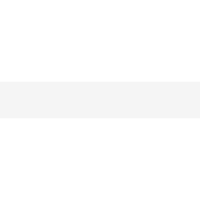


Prompt: The image shows a stylized icon of a pin or marker, which is commonly used to represent location or marking a spot.


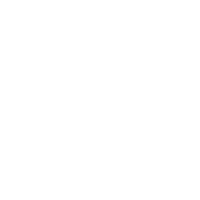


Prompt: A cartoon character of a teacher with dark hair, glasses, and purple clothing, holding a red book in front of a chalkboard.


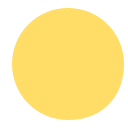


Prompt: The image contains a black circular logo or icon on a white background.


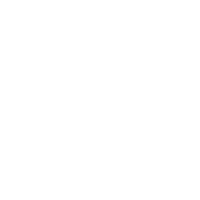


Prompt: A black icon featuring a stylized document with three horizontal black lines representing text, contained within a larger black border that gives the appearance of a tilted rectangle against a white background.


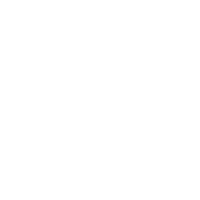

In [ ]:
from IPython.display import SVG, display

test = pd.read_csv(ROOT / "data" / "raw" / "test.csv")
sub = pd.read_csv(ROOT / "submissions" / "submission_better_inference.csv")

for _ in range(5):
    r = sub.sample(1).iloc[0]
    prompt = test[test["id"] == r["id"]]["prompt"].values[0]
    print("Prompt:", prompt)
    display(SVG(r["svg"]))
    print()